In [2]:
import astropy.io.fits as pf
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import os
import subprocess
import importlib as imp
import copy
import scipy.stats
from matplotlib.pyplot import cm
from scipy.stats import kde
import figure_subroutines as subs
from astropy import units as u
from astropy.coordinates import SkyCoord
from pylab import *
from matplotlib import ticker

In [4]:
dirty_hdu = fits.open('../GMIMS_SUMMER2019/RM_SYNTH/RFI_FIX_v3/FDF_tot_dirty.fits')
dirty_hdr = dirty_hdu[0].header
dirty_data = dirty_hdu[0].data

dirtyQ_hdu = fits.open('../GMIMS_SUMMER2019/RM_SYNTH/RFI_FIX_v3/FDF_real_dirty.fits')
dirtyQ_hdr = dirtyQ_hdu[0].header
dirtyQ_data = dirtyQ_hdu[0].data

dirtyU_hdu = fits.open('../GMIMS_SUMMER2019/RM_SYNTH/RFI_FIX_v3/FDF_im_dirty.fits')
dirtyU_hdr = dirtyU_hdu[0].header
dirtyU_data = dirtyU_hdu[0].data

lon,lat,RMarr = subs.make_axis_lists_3D(dirty_hdr)

print(RMarr)
print(dirty_data.shape)

[-2500. -2495. -2490. ...  2490.  2495.  2500.]
(1001, 360, 720)


In [50]:
rms_map_old = np.nanmean(dirty_data[abs(RMarr)>500],axis=0)

In [51]:
rms_map = np.sqrt(np.nanmean((dirty_data[abs(RMarr)>500])**2,axis=0))

In [52]:
rms_map_old_flat = rms_map_old.flatten()
rms_map_flat = rms_map.flatten()

0.008724826
0.010268561


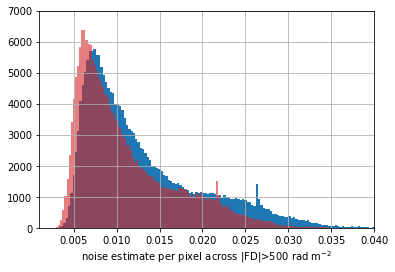

In [75]:
plt.hist(rms_map_flat, bins=1500)  
plt.hist(rms_map_old_flat, bins=1500,alpha=0.6,color='C3')
plt.xlim(0.001,0.04)
plt.ylim(0,7000)
plt.xlabel('noise estimate per pixel across |FD|>500 rad m$^{-2}$')
plt.grid()

noise = np.nanmean(rms_map_flat)
noise_old = np.nanmean(rms_map_old_flat)

print(noise_old)
print(noise)
plt.savefig('FIGURES/GMIMS_rms_histograms.pdf')

In [64]:
map_rms = np.sqrt(np.nanmean(dirty_data**2,axis=(1,2)))


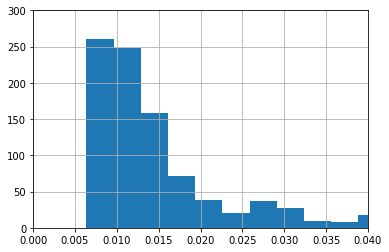

In [68]:
plt.hist(map_rms, bins=50)
plt.xlim(0.0,0.04)
plt.ylim(0,300)
plt.grid()

In [12]:
testQ = dirtyQ_data[abs(RMarr)>500,:,:]

#plt.hist(testQ, bins=50)
#plt.xlim(-0.05,0.05)
#plt.ylim(0,100)
#plt.grid()

testQ_sigma = np.nanstd(testQ)
print(testQ_sigma)

0.009349352
